In [1]:
import os
import pathlib
import datetime

import numpy as np
import geoutils as gu
import xdem

import geomulticorr as gmc
from geomulticorr.correlation import ASP

from geomulticorr.utils import gmc_functions

import matplotlib.pyplot as plt

geomulticorr 0.1.0
-------------
telenvi developer version
-------------


/home/cusicand/miniconda3/envs/gmc_env/lib/python3.12/site-packages/richdem/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
session = gmc.open_gmc_session(target_directory_path=pathlib.Path('/home/cusicand/03_Data/GMC_projects/MultiSensor'), epsg_code=2154)

[ GMC ✓ ] : GMC project structure found
[ GMC 🚀 ] : Session 'MultiSensor' initialized.


In [3]:
# Get the forward pair
pairs = session.get_pairs()
pair = [p for p in pairs if p.pa_direction == "forward"][2]
print(pair.pa_key)

MontVallon_2019-08-03-planetscope_2020-08-26-planetscope


In [4]:
# Load displacement and CC rasters
left = gu.Raster(pair.pa_left_link_path)
right = gu.Raster(pair.pa_right_link_path)
goodPixMap = gu.Raster(pair.pa_disparity_f_path, bands=[3])
xDisp = gu.Raster(pair.pa_ew_path)
yDisp = gu.Raster(pair.pa_ns_path)
cc = gu.Raster(pair.pa_cc_path)   # -ncc.tif from ASP

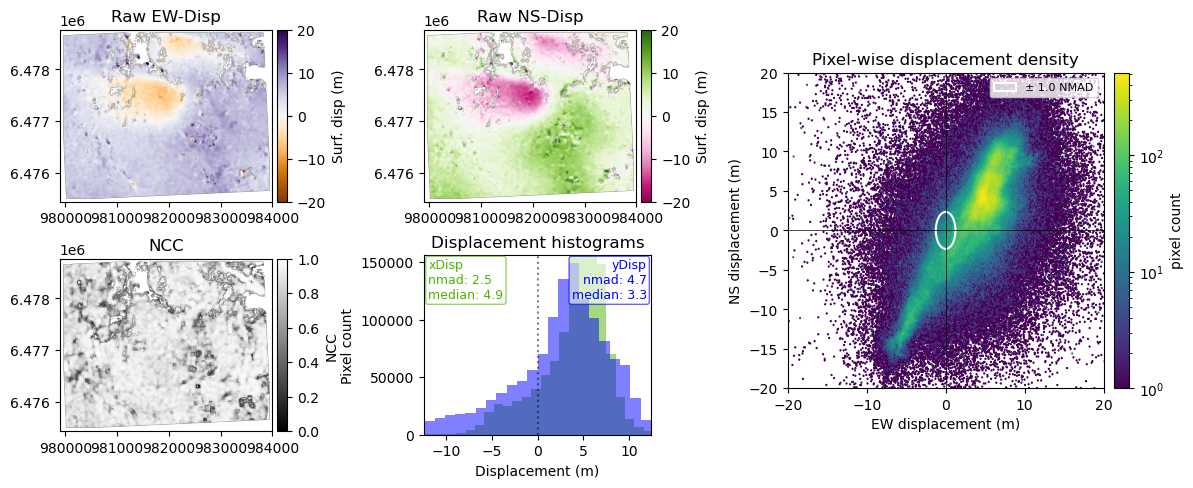

In [5]:
fig = gmc_functions.plot_show_raw_results(xDisp, yDisp, cc, figsize=(12, 5))

In [7]:
dem = gu.Raster("/home/cusicand/03_Data/GMC_projects/MontVallon_Res-0.5_CompElev-mean_merged.tif")

In [8]:
dem_ref = dem.reproject(xDisp, resampling="bilinear", res=1.5)

In [9]:
outlines = gu.Vector("/home/cusicand/03_Data/GMC_projects/MontVallon_poly.gpkg")

## Outlier removal

In [10]:
# --- OutlierFilter ---
of = gmc.OutlierFilter(threshold=(-10, 10))
xof, yof = of.apply(xDisp, yDisp)
print("OutlierFilter:")
print(f"  EW masked pixels before: {xDisp.data.mask.sum()}  after: {xof.data.mask.sum()}")
print(f"  NS masked pixels before: {yDisp.data.mask.sum()}  after: {yof.data.mask.sum()}")

OutlierFilter:
  EW masked pixels before: 65264  after: 66561
  NS masked pixels before: 65264  after: 118488


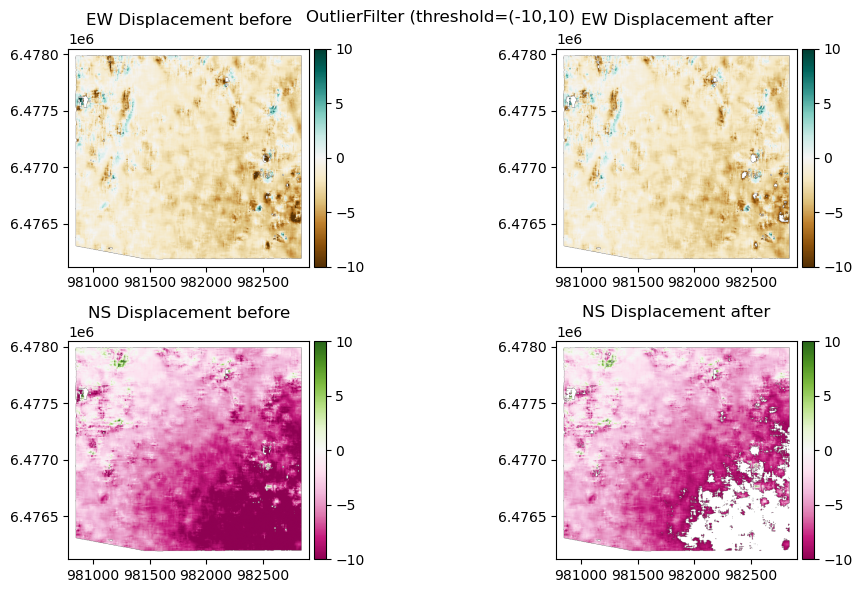

In [11]:
vmax=10
fig, axs = plt.subplot_mosaic([['a)', 'b)'],
                            ['c)', 'd)']], figsize=(12,6),)
xDisp.plot(ax=axs['a)'], vmin=-vmax, vmax=vmax, cmap='BrBG', title='EW Displacement before')
xof.plot(ax=axs['b)'], vmin=-vmax, vmax=vmax, cmap='BrBG', title='EW Displacement after')
yDisp.plot(ax=axs['c)'], vmin=-vmax, vmax=vmax, cmap='PiYG', title='NS Displacement before')
yof.plot(ax=axs['d)'], vmin=-vmax, vmax=vmax, cmap='PiYG', title='NS Displacement after')
fig.suptitle("OutlierFilter (threshold=(-10,10)")
plt.show()

## CC filter

In [12]:
# --- CCFilter ---
ccf = gmc.CCFilter(cc_threshold=0.5)
xcc, ycc = ccf.apply(xof, yof, cc=cc)
print("\nCCFilter (threshold=0.5):")
print(f"  EW masked pixels before: {xof.data.mask.sum()}  after: {xcc.data.mask.sum()}")
print(f"  NS masked pixels before: {yof.data.mask.sum()}  after: {ycc.data.mask.sum()}")



CCFilter (threshold=0.5):
  EW masked pixels before: 66561  after: 91682
  NS masked pixels before: 118488  after: 139456


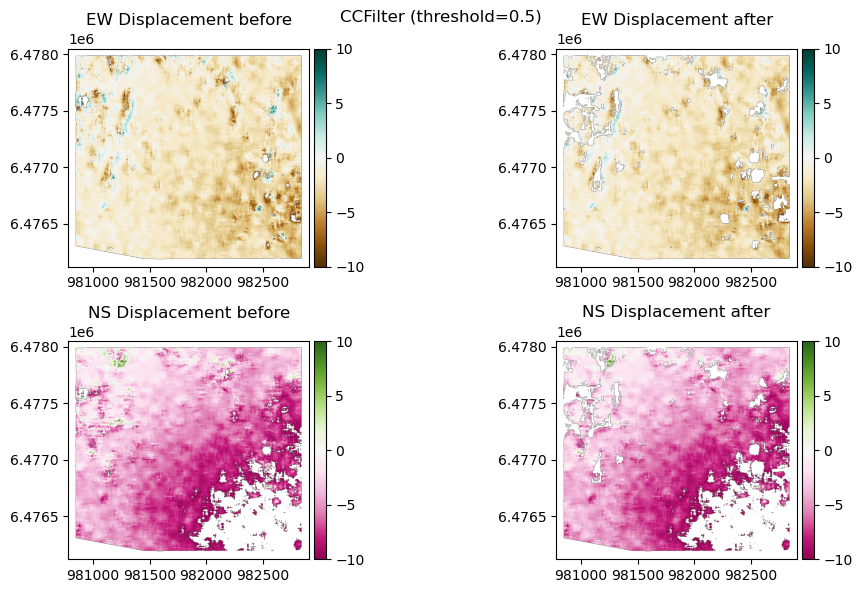

In [13]:
vmax = 10
fig, axs = plt.subplot_mosaic([['a)', 'b)'],
                            ['c)', 'd)']],
                            figsize=(12,6))
xof.plot(ax=axs['a)'], vmin=-vmax, vmax=vmax, cmap='BrBG', title='EW Displacement before')
xcc.plot(ax=axs['b)'], vmin=-vmax, vmax=vmax, cmap='BrBG', title='EW Displacement after')
yof.plot(ax=axs['c)'], vmin=-vmax, vmax=vmax, cmap='PiYG', title='NS Displacement before')
ycc.plot(ax=axs['d)'], vmin=-vmax, vmax=vmax, cmap='PiYG', title='NS Displacement after')
plt.suptitle("CCFilter (threshold=0.5)")
plt.show()

## Median filter

In [14]:
# --- MedianCentering ---
mc = gmc.MedianCentering(stat='median')
xmc, ymc = mc.apply(xcc, ycc)
print(f"\nMedianCentering:")
print(f" EW median before: {float(xcc.data.mean()):.4f}  after: {float(xmc.data.mean()):.4f}")
print(f" NS median before: {float(ycc.data.mean()):.4f}  after: {float(ymc.data.mean()):.4f}")
print(f" Shifts applied — x_shift={mc.meta['x_shift']:.4f}, y_shift={mc.meta['y_shift']:.4f}")



MedianCentering:
 EW median before: -2.0360  after: -0.0914
 NS median before: -5.0843  after: -0.1075
 Shifts applied — x_shift=-1.9446, y_shift=-4.9768


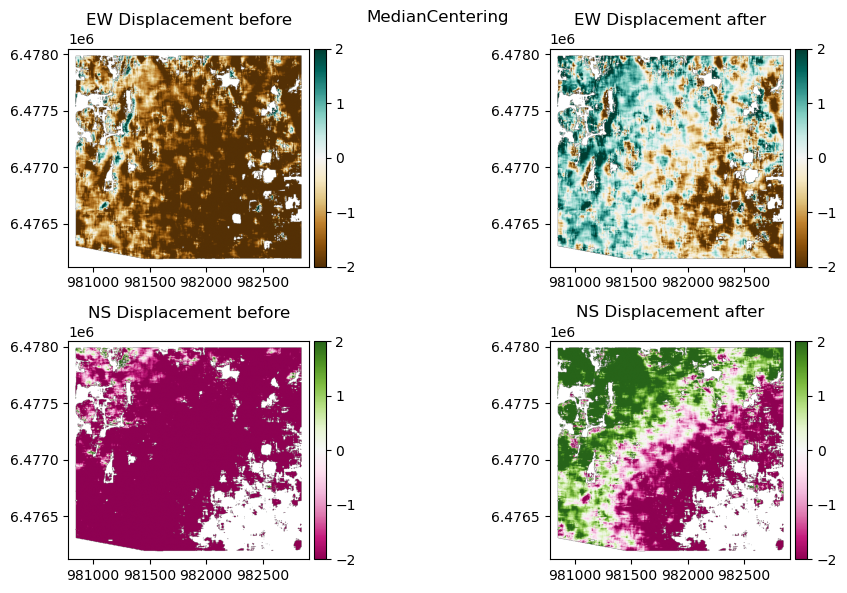

In [15]:
vmax=2
fig, axs = fig, axs = plt.subplot_mosaic([['a)', 'b)'],
                            ['c)', 'd)']],
                            figsize=(12,6))
xcc.plot(ax=axs['a)'], vmin=-vmax, vmax=vmax, cmap='BrBG', title='EW Displacement before')
xmc.plot(ax=axs['b)'], vmin=-vmax, vmax=vmax, cmap='BrBG', title='EW Displacement after')
ycc.plot(ax=axs['c)'], vmin=-vmax, vmax=vmax, cmap='PiYG', title='NS Displacement before')
ymc.plot(ax=axs['d)'], vmin=-vmax, vmax=vmax, cmap='PiYG', title='NS Displacement after')
plt.suptitle("MedianCentering")
plt.show()

## Test `RampCorrection` and `TopoCorrection`

Both corrections require a `stable_mask` — a GeoDataFrame (or file path) containing
the **moving-area polygon** (e.g. glacier outline).  Pixels **outside** that polygon
are used to fit the regression.  For a quick smoke-test, an empty GeoDataFrame means
*all valid pixels* are used for fitting.

In [19]:
slope = xdem.terrain.slope(dem_ref)
slope_mask = (slope.data < 35).filled(False)
del slope

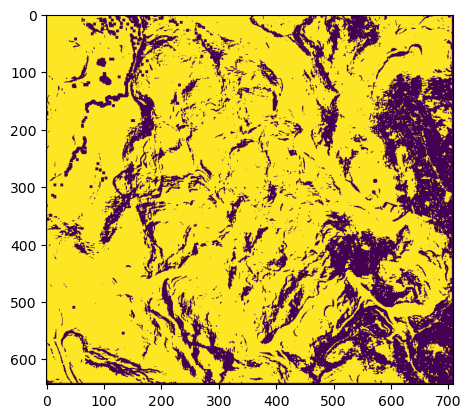

In [20]:
plt.imshow(slope_mask)

In [21]:
rg_mask = outlines.create_mask(dem_ref)

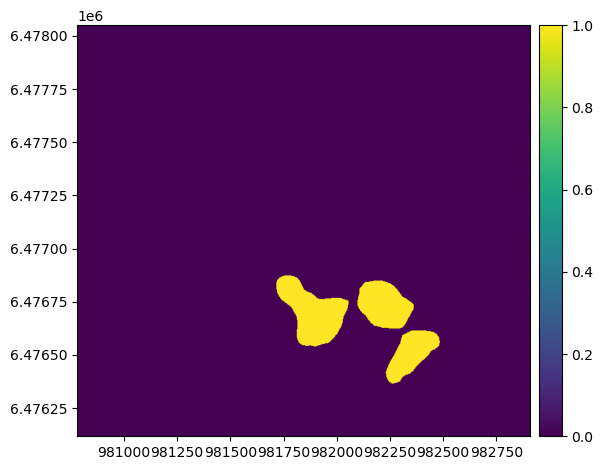

In [22]:
rg_mask.plot()

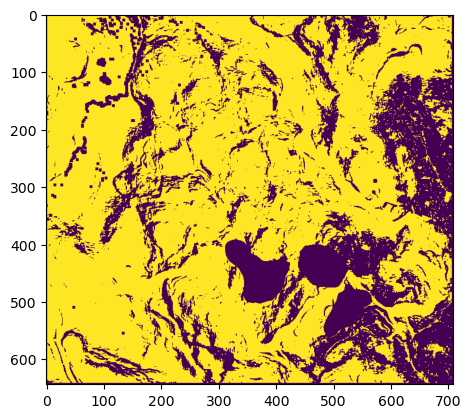

In [23]:
inlier_mask = slope_mask & ~rg_mask.data.filled(False)
plt.imshow(inlier_mask)

### RampCorrection (linear XY plane, no DEM)

In [24]:
ramp = gmc.RampCorrection(lambda_reg=1e-6)
xr, yr = ramp.apply(xcc, ycc, stable_mask=inlier_mask)

print('RampCorrection coefficients:')
print(f"  EW → a={ramp.meta['xDisp']['a']:.6f}  b={ramp.meta['xDisp']['b']:.6f}  "
      f"d={ramp.meta['xDisp']['d']:.4f}  R²={ramp.meta['xDisp']['r2']:.4f}")
print(f"  NS → a={ramp.meta['yDisp']['a']:.6f}  b={ramp.meta['yDisp']['b']:.6f}  "
      f"d={ramp.meta['yDisp']['d']:.4f}  R²={ramp.meta['yDisp']['r2']:.4f}")

print(f"\nEW median before: {float(np.ma.median(xDisp.data)):.4f}  "
      f"after: {float(np.ma.median(xr.data)):.4f}")
print(f"NS median before: {float(np.ma.median(yDisp.data)):.4f}  "
      f"after: {float(np.ma.median(yr.data)):.4f}")

RampCorrection coefficients:
  EW → a=-0.001941  b=-0.003533  d=-0.1416  R²=0.2962
  NS → a=-0.010392  b=-0.008146  d=0.7578  R²=0.6632

EW median before: -1.9524  after: 0.0418
NS median before: -5.5024  after: -0.1431


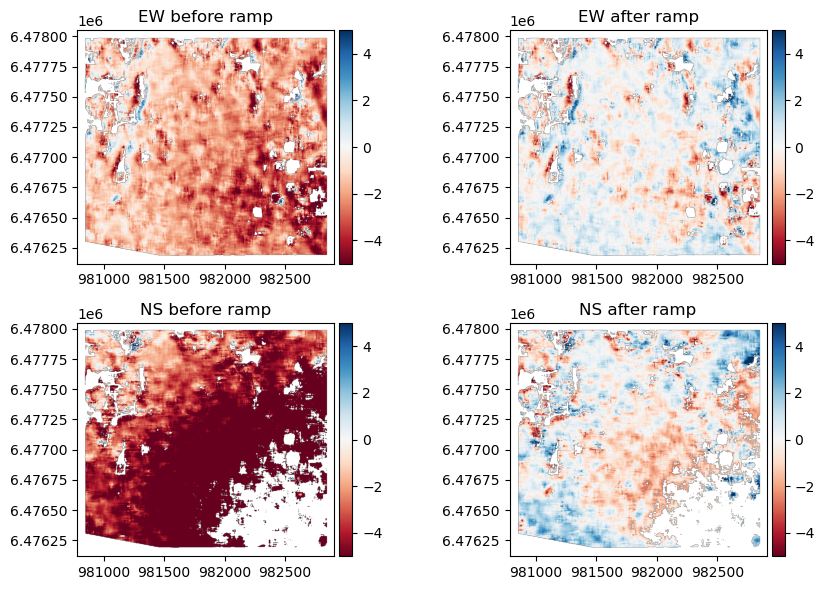

In [25]:
vmax = 5
fig, axs = plt.subplot_mosaic(
    [['EW before', 'EW after'], ['NS before', 'NS after']],
    figsize=(12, 6),
)
xcc.plot(ax=axs['EW before'], vmin=-vmax, vmax=vmax, cmap='RdBu', title='EW before ramp')
xr.plot(ax=axs['EW after'],    vmin=-vmax, vmax=vmax, cmap='RdBu', title='EW after ramp')
ycc.plot(ax=axs['NS before'], vmin=-vmax, vmax=vmax, cmap='RdBu', title='NS before ramp')
yr.plot(ax=axs['NS after'],    vmin=-vmax, vmax=vmax, cmap='RdBu', title='NS after ramp')
plt.tight_layout()
plt.show()

### TopoCorrection — DEM preparation

The DEM **must have the same shape** as the displacement rasters.  If you have a
real DEM, reproject it with `dem_raw.reproject(xDisp)`.  Below is a synthetic
tilted plane for testing.

### TopoCorrection — linear order

In [30]:
topo_lin = gmc.TopoCorrection(order='linear', lambda_reg=1e-6)
xt_lin, yt_lin = topo_lin.apply(xr, yr, dem=dem_ref, stable_mask=inlier_mask)

print('TopoCorrection (linear) coefficients:')
for band, key in [('EW', 'xDisp'), ('NS', 'yDisp')]:
    m = topo_lin.meta[key]
    print(f'{band} → a={m["row_slope"]:.6f}  b={m["col_slope"]:.6f}\n'
          f'c(DEM)={m["dem_slope"]:.6f}  d={m["intercept"]:.4f}  R²={m["r2"]:.4f}')

TopoCorrection (linear) coefficients:
EW → a=0.002332  b=0.002413
c(DEM)=-0.003143  d=5.9955  R²=0.0276
NS → a=0.008972  b=0.009425
c(DEM)=-0.013103  d=25.3433  R²=0.2432


### TopoCorrection — quadratic order

In [ ]:
topo_quad = gmc.TopoCorrection(order='quadratic', lambda_reg=1e-6)
xt_quad, yt_quad = topo_quad.apply(xr, yr, dem=dem_ref, stable_mask=inlier_mask)

print('TopoCorrection (quadratic) coefficients:')
for band, key in [('EW', 'xDisp'), ('NS', 'yDisp')]:
    m = topo_quad.meta[key]
    print(f'{band} → fz(DEM)={m["c_dem"]:.6f}  R²={m["r2"]:.4f}')

# Compare medians
print(f"\nEW median before: {float(np.ma.median(xDisp.data)):.4f}")
print(f"EW median after (quadratic): {float(np.ma.median(xt_quad.data)):.4f}")

TopoCorrection (quadratic) coefficients:
  EW → fz(DEM)=-0.283788  R²=0.0388
  NS → fz(DEM)=-1.821607  R²=0.2668

EW median before: -1.9524
EW median after (quadratic): 0.0409


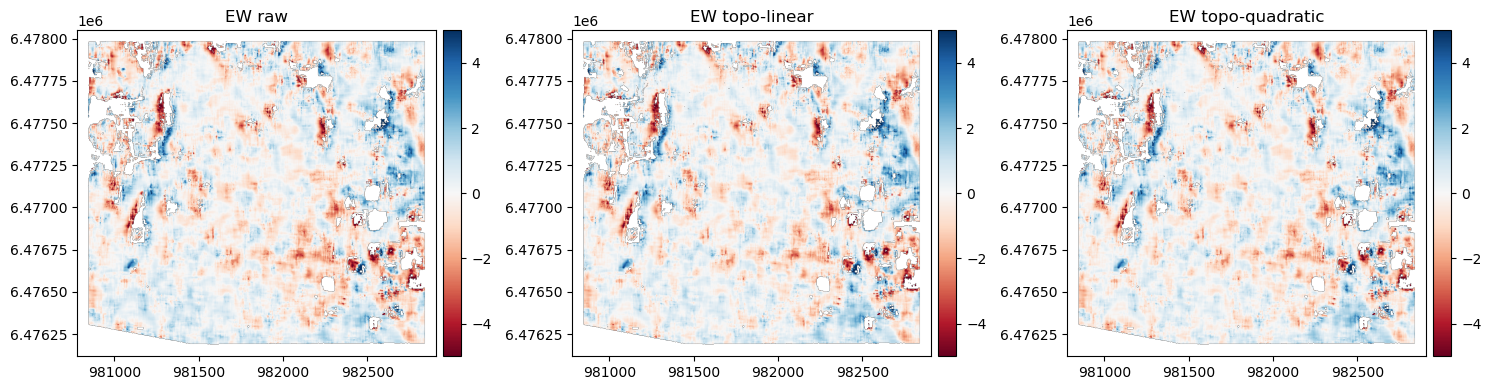

In [33]:
# Side-by-side comparison: raw vs linear vs quadratic topo correction
vmax = 5
fig, axs = plt.subplot_mosaic(
    [['raw', 'linear', 'quadratic']],
    figsize=(15, 4),
)
xr.plot(ax=axs['raw'],       vmin=-vmax, vmax=vmax, cmap='RdBu', title='EW raw')
xt_lin.plot(ax=axs['linear'],   vmin=-vmax, vmax=vmax, cmap='RdBu', title='EW topo-linear')
xt_quad.plot(ax=axs['quadratic'], vmin=-vmax, vmax=vmax, cmap='RdBu', title='EW topo-quadratic')
plt.tight_layout()
plt.show()

## Test pipeline composition with `+` operator

In [44]:
# Build a pipeline step by step with +
pipeline = (gmc.OutlierFilter(threshold=(-10, 10))
            + gmc.CCFilter(cc_threshold=0.5)
            + gmc.MedianCentering()
            + gmc.RampCorrection()
            + gmc.TopoCorrection(order='quadratic')
            )

In [45]:
print(repr(pipeline))
# → CorrectionPipeline([OutlierFilter -> CCFilter -> MedianCentering])

CorrectionPipeline([OutlierFilter -> CCFilter -> MedianCentering -> RampCorrection -> TopoCorrection])


In [46]:
# Apply the pipeline
xc, yc = pipeline.apply(xDisp, yDisp, cc=cc, stable_mask=inlier_mask, dem=dem_ref)

In [47]:
# Check mask grows monotonically through the pipeline
print(f"Input  — EW masked pixels: {xDisp.data.mask.sum()}")
print(f"Output — EW masked pixels: {xc.data.mask.sum()}")
assert xc.data.mask.sum() >= xDisp.data.mask.sum(), "Mask should only grow"

Input  — EW masked pixels: 65264
Output — EW masked pixels: 92193


In [48]:
# Inspect per-step diagnostics
for i, info in pipeline.meta.items():
    print(f"  Step {i}: {info['step']}  diagnostics={info['diagnostics']}")

  Step 0: OutlierFilter  diagnostics={}
  Step 1: CCFilter  diagnostics={}
  Step 2: MedianCentering  diagnostics={'x_shift': -1.9446133375167847, 'y_shift': -4.976816296577454}
  Step 3: RampCorrection  diagnostics={'xDisp': {'a': -0.0019411402215227015, 'b': -0.003532516393520871, 'd': 1.803031248177844, 'r2': 0.296151399210812}, 'yDisp': {'a': -0.010392417788380725, 'b': -0.008145959071094352, 'd': 5.734610690437423, 'r2': 0.6632283296573103}}
  Step 4: TopoCorrection  diagnostics={'xDisp': {'c_bias': -0.04402109540438781, 'c_row2': 0.06819645308869916, 'c_col2': -0.03866804303317692, 'c_rowcol': -0.12019653156592684, 'c_row': 0.1910855096728728, 'c_col': 0.21476213466744157, 'c_dem': -0.2837878534706962, 'r2': 0.038759533979542904}, 'yDisp': {'c_bias': -0.3086082189345835, 'c_row2': 0.19650534393783378, 'c_col2': 0.12769209778092183, 'c_rowcol': 0.059551066024265784, 'c_row': 1.3160288550908716, 'c_col': 1.4808124888154004, 'c_dem': -1.821606595393883, 'r2': 0.2668312890714143}}


##  Save corrected stats and inspect the JSON

In [50]:
import json
import geomulticorr.stats as gmc_stats

# Apply a correction pipeline
pipeline = gmc.CCFilter(0.5) + gmc.OutlierFilter((-10, 10)) + gmc.MedianCentering() + gmc.RampCorrection() + gmc.TopoCorrection(order='quadratic')
xc, yc = pipeline.apply(xDisp, yDisp, cc=cc, stable_mask=inlier_mask, dem=dem_ref)

# Save stats under the pipeline step name
gmc_stats.save_corrected_stats(pair, xc, yc, "CCFilter")

# Apply MedianCentering on its own and record that too
xmc, ymc = gmc.MedianCentering().apply(xc, yc)
gmc_stats.save_corrected_stats(pair, xmc, ymc, "MedianCentering")

xrc, yrc = gmc.RampCorrection(lambda_reg=1e-6).apply(xc, yc, stable_mask=inlier_mask)
gmc_stats.save_corrected_stats(pair, xrc, yrc, "RampCorrection")

xtc, ytc = gmc.TopoCorrection(order='quadratic', lambda_reg=1e-6).apply(xrc, yrc, dem=dem_ref, stable_mask=inlier_mask)
gmc_stats.save_corrected_stats(pair, xtc, ytc, "TopoCorrection")

# Read back the JSON and inspect
stats = json.loads(pair.pa_stats_path.read_text())
cs = stats["corrected_stats"]

print("Keys in corrected_stats:", list(cs.keys()))
for corr_name, entry in cs.items():
    ew = entry["ew"]
    ns = entry["ns"]
    print(f"\n  [{corr_name}]")
    print(f"    EW — median={ew['median']:.4f}  nmad={ew['nmad']:.4f}  valid={ew['count_valid']}")
    print(f"    NS — median={ns['median']:.4f}  nmad={ns['nmad']:.4f}  valid={ns['count_valid']}")

[ GeoMultiCorr 📊 ] : Corrected stats saved for 'MontVallon_2018-08-26-planetscope_2019-08-03-planetscope' [CCFilter] (ew valid=364403, ns valid=316650)
[ GeoMultiCorr 📊 ] : Corrected stats saved for 'MontVallon_2018-08-26-planetscope_2019-08-03-planetscope' [MedianCentering] (ew valid=364402, ns valid=316650)


/home/cusicand/miniconda3/envs/gmc_env/lib/python3.12/site-packages/geoutils/raster/raster.py:1860: UserWarning: Unmasked values equal to the nodata value found in data array. They are now masked.
 If this happened when creating or updating the array, to silence this warning, convert nodata values in the array to np.nan or mask them with np.ma.masked prior to creating or updating the raster.
If this happened during a numerical operation, use astype() prior to the operation to convert to a data type that won't derive the nodata values (e.g., a float type).
  warnings.warn(


[ GeoMultiCorr 📊 ] : Corrected stats saved for 'MontVallon_2018-08-26-planetscope_2019-08-03-planetscope' [RampCorrection] (ew valid=364403, ns valid=316650)
[ GeoMultiCorr 📊 ] : Corrected stats saved for 'MontVallon_2018-08-26-planetscope_2019-08-03-planetscope' [TopoCorrection] (ew valid=364403, ns valid=316650)
Keys in corrected_stats: ['CCFilter', 'MedianCentering', 'RampCorrection', 'TopoCorrection']

  [CCFilter]
    EW — median=0.0409  nmad=0.7756  valid=364403
    NS — median=-0.0325  nmad=0.8815  valid=316650

  [MedianCentering]
    EW — median=0.0000  nmad=0.7756  valid=364402
    NS — median=0.0000  nmad=0.8815  valid=316650

  [RampCorrection]
    EW — median=0.0409  nmad=0.7756  valid=364403
    NS — median=-0.0325  nmad=0.8815  valid=316650

  [TopoCorrection]
    EW — median=0.0409  nmad=0.7756  valid=364403
    NS — median=-0.0325  nmad=0.8815  valid=316650


### Full pipeline: mask + correct + save stats

In [ ]:
import geomulticorr.stats as gmc_stats

# Full pipeline: CC filter → outlier removal → deramp → median centering
full_pipeline = (
    gmc.CCFilter(cc_threshold=0.5)
    + gmc.OutlierFilter(threshold=(-10, 10))
    + gmc.RampCorrection(lambda_reg=1e-6)
    + gmc.MedianCentering()
)
print(repr(full_pipeline))

xfinal, yfinal = full_pipeline.apply(
    xDisp, yDisp,
    cc=cc,
    stable_mask=stable_mask,
)

# Persist corrected stats to the pair JSON
gmc_stats.save_corrected_stats(pair, xfinal, yfinal, str(full_pipeline))

# Verify the JSON
stats_dict = json.loads(pair.pa_stats_path.read_text())
cs = stats_dict['corrected_stats']
print(f"\nKeys in corrected_stats: {list(cs.keys())}")
key = str(full_pipeline)
print(f"\n[{key}]")
print(f"  EW — median={cs[key]['ew']['median']:.4f}  nmad={cs[key]['ew']['nmad']:.4f}  "
      f"valid={cs[key]['ew']['count_valid']}")
print(f"  NS — median={cs[key]['ns']['median']:.4f}  nmad={cs[key]['ns']['nmad']:.4f}  "
      f"valid={cs[key]['ns']['count_valid']}")